# FlyRank ML Internship Capstone

## Notebook 1 – Exploratory Data Analysis (EDA)

### Lane
Refresh / Content Opportunity Scoring

### Objective
Explore the FlyRank warehouse data, understand its structure, identify patterns, detect missing values, and prepare features for machine learning.

---

In [1]:
!pip -q install duckdb huggingface_hub pandas matplotlib scikit-learn

In [2]:
import os, getpass

# Token order: env var -> Colab Secret -> prompt (last resort).
# Use a Colab Secret named HF_TOKEN (the key panel on the left) so the prompt never
# fires: if Colab reconnects while a getpass prompt is open, the kernel waits on it
# forever ('Resuming execution...') and you have to restart the runtime.
HF_TOKEN = os.environ.get('HF_TOKEN')
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get('HF_TOKEN')
    except Exception:
        pass
HF_TOKEN = HF_TOKEN or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')


In [3]:
import duckdb

con = duckdb.connect()

con.execute(f"""
CREATE OR REPLACE SECRET hf (
TYPE huggingface,
TOKEN '{HF_TOKEN}'
)
""")

REL = "hf://datasets/FlyRank/internship-warehouse"

TABLES = {
    "dim_clients": f"read_parquet('{REL}/dim_clients.parquet')",
    "dim_content": f"read_parquet('{REL}/dim_content.parquet')",
    "fact_daily": f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
    "fact_daily_sample": f"read_parquet('{REL}/fact_content_daily_performance_sample.parquet')",
    "fact_query_90d": f"read_parquet('{REL}/fact_content_query_90d.parquet')"
}

print("Connected Successfully!")

Connected Successfully!


In [4]:
for name, src in TABLES.items():
    rows = con.sql(f"SELECT COUNT(*) FROM {src}").fetchone()[0]
    print(f"{name:20} : {rows:,}")

dim_clients          : 104
dim_content          : 519,606


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

fact_daily           : 78,835,655
fact_daily_sample    : 11,694,072
fact_query_90d       : 2,414,248


# Data Extraction

We extract page-level performance metrics from the FlyRank warehouse.

The dataset is aggregated into content-level features for later machine learning analysis.

In [5]:
features = con.sql(f"""
WITH latest_date AS (
    SELECT MAX(report_date) AS max_date
    FROM {TABLES['fact_daily']}
),

page_metrics AS (

SELECT

client_hash_id,
content_hash_id,

SUM(
CASE
WHEN report_date > (SELECT max_date - INTERVAL 30 DAY FROM latest_date)
THEN gsc_impressions
ELSE 0
END
) AS imp_last30,

SUM(
CASE
WHEN report_date BETWEEN
(SELECT max_date - INTERVAL 60 DAY FROM latest_date)
AND
(SELECT max_date - INTERVAL 31 DAY FROM latest_date)
THEN gsc_impressions
ELSE 0
END
) AS imp_prev30,

SUM(
CASE
WHEN report_date > (SELECT max_date - INTERVAL 30 DAY FROM latest_date)
THEN gsc_clicks
ELSE 0
END
) AS clk_last30,

SUM(
CASE
WHEN report_date BETWEEN
(SELECT max_date - INTERVAL 60 DAY FROM latest_date)
AND
(SELECT max_date - INTERVAL 31 DAY FROM latest_date)
THEN gsc_clicks
ELSE 0
END
) AS clk_prev30,

AVG(
CASE
WHEN report_date > (SELECT max_date - INTERVAL 30 DAY FROM latest_date)
THEN gsc_avg_position
END
) AS pos_last30,

AVG(
CASE
WHEN report_date BETWEEN
(SELECT max_date - INTERVAL 60 DAY FROM latest_date)
AND
(SELECT max_date - INTERVAL 31 DAY FROM latest_date)
THEN gsc_avg_position
END
) AS pos_prev30

FROM {TABLES['fact_daily']}

GROUP BY
client_hash_id,
content_hash_id

)

SELECT *

FROM page_metrics

WHERE imp_prev30 >= 100

""").df()

print(features.shape)

features.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(111033, 8)


,client_hash_id,content_hash_id,imp_last30,imp_prev30,clk_last30,clk_prev30,pos_last30,pos_prev30
0,client_9958f0a7ae1df715,content_cd36f906cac66324,166.0,200.0,0.0,0.0,65.642404,74.898151
1,client_9958f0a7ae1df715,content_28de1fb24f0fb4a8,291.0,340.0,0.0,0.0,65.834991,66.210518
2,client_9958f0a7ae1df715,content_6afb4ede795f9338,310.0,275.0,0.0,0.0,73.094898,72.976096
3,client_9958f0a7ae1df715,content_12415a5ac1570217,69.0,102.0,0.0,0.0,42.761095,39.467971
4,client_9958f0a7ae1df715,content_875ebebd0b4b106d,163.0,135.0,0.0,0.0,28.649639,35.018813


In [6]:
import numpy as np

# Impression growth
features["impression_growth"] = (
    (features["imp_last30"] - features["imp_prev30"])
    / features["imp_prev30"]
)

# Click growth
features["click_growth"] = np.where(
    features["clk_prev30"] > 0,
    (features["clk_last30"] - features["clk_prev30"])
    / features["clk_prev30"],
    0
)

# Position change
features["position_change"] = (
    features["pos_last30"] - features["pos_prev30"]
)

# Current CTR
features["ctr_last30"] = np.where(
    features["imp_last30"] > 0,
    features["clk_last30"] / features["imp_last30"],
    0
)

# Previous CTR
features["ctr_prev30"] = np.where(
    features["imp_prev30"] > 0,
    features["clk_prev30"] / features["imp_prev30"],
    0
)

# CTR improvement
features["ctr_change"] = (
    features["ctr_last30"] - features["ctr_prev30"]
)

features.head()

,client_hash_id,content_hash_id,imp_last30,imp_prev30,clk_last30,clk_prev30,pos_last30,pos_prev30,impression_growth,click_growth,position_change,ctr_last30,ctr_prev30,ctr_change
0,client_9958f0a7ae1df715,content_cd36f906cac66324,166.0,200.0,0.0,0.0,65.642404,74.898151,-0.170000,0.0,-9.255747,0.0,0.0,0.0
1,client_9958f0a7ae1df715,content_28de1fb24f0fb4a8,291.0,340.0,0.0,0.0,65.834991,66.210518,-0.144118,0.0,-0.375527,0.0,0.0,0.0
2,client_9958f0a7ae1df715,content_6afb4ede795f9338,310.0,275.0,0.0,0.0,73.094898,72.976096,0.127273,0.0,0.118802,0.0,0.0,0.0
3,client_9958f0a7ae1df715,content_12415a5ac1570217,69.0,102.0,0.0,0.0,42.761095,39.467971,-0.323529,0.0,3.293125,0.0,0.0,0.0
4,client_9958f0a7ae1df715,content_875ebebd0b4b106d,163.0,135.0,0.0,0.0,28.649639,35.018813,0.207407,0.0,-6.369174,0.0,0.0,0.0


In [7]:
features.describe()

,imp_last30,imp_prev30,clk_last30,clk_prev30,pos_last30,pos_prev30,impression_growth,click_growth,position_change,ctr_last30,ctr_prev30,ctr_change
count,111033.000000,111033.000000,111033.000000,111033.000000,109804.000000,111033.000000,111033.000000,111033.000000,109804.000000,111033.000000,111033.000000,111033.000000
mean,1834.899814,2293.349428,6.941900,7.939315,20.521546,19.856523,-0.070668,0.078145,0.729379,0.003799,0.003281,0.000517
std,6772.130206,6913.445026,32.245236,32.832631,17.885013,15.134580,1.888783,1.544410,11.017717,0.007867,0.004932,0.007753
min,0.000000,100.000000,0.000000,0.000000,0.000000,0.331136,-1.000000,-1.000000,-81.943678,0.000000,0.000000,-0.123030
25%,129.000000,231.000000,0.000000,0.000000,7.627717,8.577783,-0.648674,-0.500000,-3.774217,0.000000,0.000000,-0.001206
50%,386.000000,566.000000,1.000000,1.000000,13.619837,14.710249,-0.393103,0.000000,-0.011574,0.001749,0.001695,0.000000
75%,1287.000000,1799.000000,5.000000,5.000000,27.902763,26.832377,0.002885,0.000000,4.144741,0.005236,0.004673,0.001558
max,615012.000000,579421.000000,3817.000000,4114.000000,579.000000,92.266533,323.769321,71.657143,562.562363,1.000000,0.142857,1.000000


In [8]:
features.isnull().sum()

,0
client_hash_id,0
content_hash_id,0
imp_last30,0
imp_prev30,0
clk_last30,0
clk_prev30,0
pos_last30,1229
pos_prev30,0
impression_growth,0
click_growth,0


In [9]:
features.to_csv("feature_dataset.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [10]:
features["pos_last30"] = features["pos_last30"].fillna(features["pos_prev30"])

features["position_change"] = features["position_change"].fillna(0)

In [11]:
features.isnull().sum()

,0
client_hash_id,0
content_hash_id,0
imp_last30,0
imp_prev30,0
clk_last30,0
clk_prev30,0
pos_last30,0
pos_prev30,0
impression_growth,0
click_growth,0


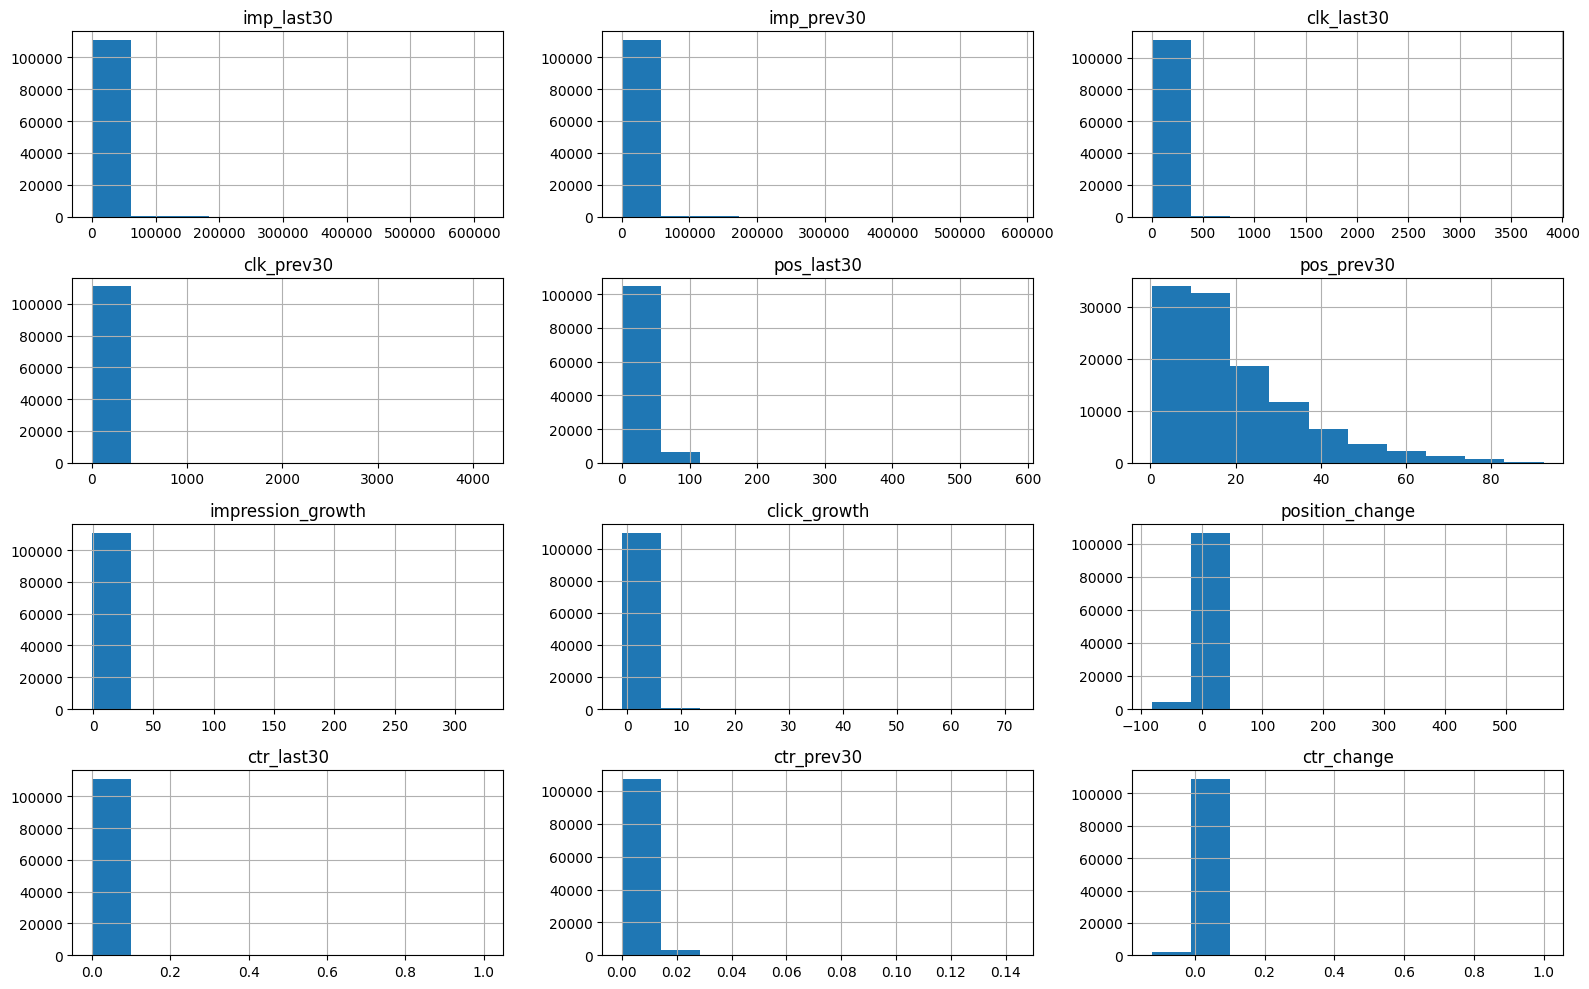

In [12]:
import matplotlib.pyplot as plt

features.hist(figsize=(16,10))

plt.tight_layout()

plt.show()

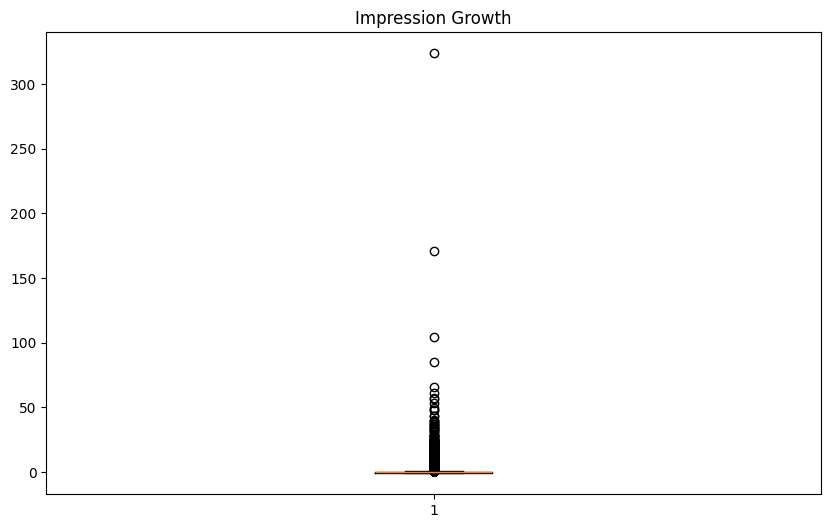

In [13]:
plt.figure(figsize=(10,6))

plt.boxplot(features["impression_growth"])

plt.title("Impression Growth")

plt.show()

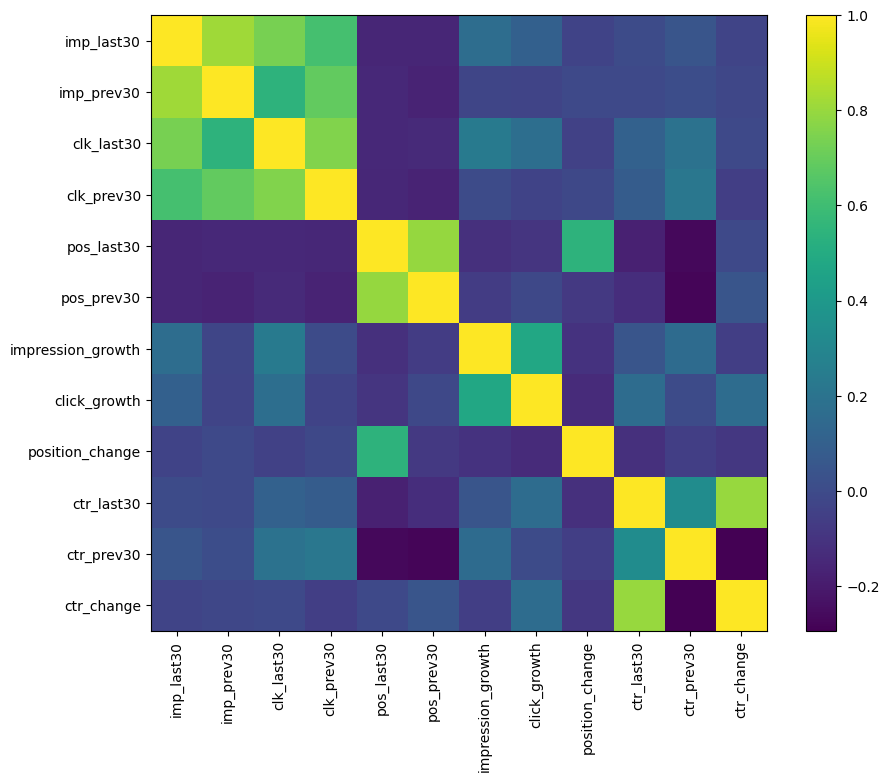

In [14]:
corr = features.corr(numeric_only=True)

plt.figure(figsize=(10,8))

plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)

plt.yticks(range(len(corr.columns)), corr.columns)

plt.show()

## EDA Summary

### Dataset

- Total pages: 111,033
- Features: 14
- Missing values handled successfully.

### Observations

- Impression distribution is highly skewed.
- Most pages experienced negative impression growth.
- Click distribution is sparse.
- Position varies considerably across pages.
- Large outliers exist and should be considered during modeling.